In [58]:
import numpy as np
import pandas as pd


In [59]:
from pathlib import Path

project_root = Path.cwd().parent
data_path=(
    project_root
    /"data"
    /"processed"
    /"Brazilian E-Commerce Public Dataset by Olist.xlsx"
)

In [60]:
df=pd.read_excel(data_path)

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113390 entries, 0 to 113389
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Unnamed: 0                     113390 non-null  int64         
 1   order_id                       113390 non-null  object        
 2   order_item_id                  113390 non-null  int64         
 3   customer_id                    113390 non-null  object        
 4   customer_unique_id             113390 non-null  object        
 5   customer_zip_code_prefix       113390 non-null  int64         
 6   customer_city                  113390 non-null  object        
 7   customer_state                 113390 non-null  object        
 8   product_id                     113390 non-null  object        
 9   product_category_name          113390 non-null  object        
 10  product_name_lenght            113390 non-null  int64         
 11  

In [62]:
df.columns

Index(['Unnamed: 0', 'order_id', 'order_item_id', 'customer_id',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'product_id', 'product_category_name',
       'product_name_lenght', 'product_description_lenght',
       'product_photos_qty', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm', 'seller_id', 'seller_city',
       'seller_state', 'seller_zip_code_prefix', 'payment_type',
       'payment_sequential', 'payment_installments', 'price', 'freight_value',
       'payment_value', 'shipping_limit_date', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'day_of_purchase', 'month_of_purchase', 'year_of_purchase',
       'month/year_of_purchase', 'order_status', 'order_unique_id'],
      dtype='object')

In [63]:
df['order_id'].nunique()

95128

In [64]:
df['order_unique_id'].nunique()

108640

In [65]:
df['customer_id'].nunique()

95128

In [66]:
print(113390/95128)

1.191972920696325


In [67]:
# Most customers buy one item.
# Some customers buy multiple items.
# Therefore,dataset is item-level, not order-level.

In [68]:
df['seller_id'].nunique()

2914

In [69]:
df['product_id'].nunique()

31625

In [70]:
df['order_id'].value_counts().sort_values(ascending=False).head(10)

order_id
895ab968e7bb0d5659d16cd74cd1650c    63
fedcd9f7ccdc8cba3a18defedd1a5547    38
ccf804e764ed5650cd8759557269dc13    26
a3725dfe487d359b5be08cac48b64ec5    24
465c2e1bee4561cb39e0db8c5993aafc    24
c6492b842ac190db807c15aff21a7dd6    24
68986e4324f6a21481df4e6e89abcf01    24
285c2e15bebd4ac83635ccc563dc71f4    22
958c6a70e60365b576dd696ad29bbca2    21
8272b63d03f5f79c56e9e4120aec44ef    21
Name: count, dtype: int64

In [71]:
df['order_item_id'].value_counts().sort_index()

order_item_id
1     99299
2      9930
3      2301
4       948
5       445
6       253
7        60
8        35
9        28
10       25
11       17
12       13
13        8
14        7
15        5
16        3
17        3
18        3
19        3
20        3
21        1
Name: count, dtype: int64

In [72]:
df[['order_id','order_item_id']].head(20)

,order_id,order_item_id
0,00010242fe8c5a6d1ba2dd792cb16214,1
1,130898c0987d1801452a8ed92a670612,1
2,532ed5e14e24ae1f0d735b91524b98b9,1
3,6f8c31653edb8c83e1a739408b5ff750,1
4,7d19f4ef4d04461989632411b7e588b9,1
5,a0f9acf0b6294ed8561e32cde1a966bc,1
6,bbf796534aaf9c59f8da8c7982db56e0,1
7,c9ef97d2854afe64a3b4488bc2836af6,2
8,c9ef97d2854afe64a3b4488bc2836af6,1
9,df2d910b8b5e5f461f67043489f9569d,1


In [73]:
df['order_delivered_customer_date'].head()

0   2017-09-20 23:43:48
1   2017-07-13 20:39:29
2   2018-06-04 18:34:26
3   2017-08-09 21:26:33
4   2017-08-24 20:04:21
Name: order_delivered_customer_date, dtype: datetime64[ns]

In [74]:
df.groupby("order_id")["order_delivered_customer_date"].nunique().value_counts()#For every individual order_id, there is only ONE unique delivery date.

order_delivered_customer_date
1    95128
Name: count, dtype: int64

In [75]:
missing= df.isnull().sum()
missing=missing[missing>0].sort_values(ascending=False)
print(missing)# this means we have zero null value

Series([], dtype: int64)


In [76]:
df.duplicated().sum()#this means we have zero diplicate values

np.int64(0)

In [77]:
df['order_id'].duplicated().sum()# means that the order is placed with same id manytimes.
#Duplicate rows are absent, but repeated order_ids indicate item-level observations. We need to decide whether to model at the item level or aggregate to the order level to avoid over-representing large orders.

np.int64(18262)

In [78]:
categorical_cols=df.select_dtypes(include='object').columns
for col in categorical_cols:
    print(f'\n{col}')
    print(df[col].nunique())


order_id
95128

customer_id
95128

customer_unique_id
92081

customer_city
4073

customer_state
27

product_id
31625

product_category_name
73

seller_id
2914

seller_city
588

seller_state
22

payment_type
4

day_of_purchase
7

month_of_purchase
12

order_status
2

order_unique_id
108640


In [79]:
df['deliver_duration']=df['order_delivered_customer_date']-df['order_purchase_timestamp']
df['deliver_duration'].head(10)

0    7 days 14:44:46
1   15 days 08:47:09
2   17 days 08:08:33
3    8 days 02:47:51
4   13 days 22:15:41
5   35 days 05:08:01
6   10 days 00:57:00
7    9 days 01:13:58
8    9 days 01:13:58
9   21 days 01:29:44
Name: deliver_duration, dtype: timedelta64[ns]

In [80]:
df['delivery_duration_days'] = (
    df['order_delivered_customer_date']
    - df['order_purchase_timestamp']
).dt.total_seconds() // (24 * 60 * 60)
df['delivery_duration_days'].head(10)

0     7.0
1    15.0
2    17.0
3     8.0
4    13.0
5    35.0
6    10.0
7     9.0
8     9.0
9    21.0
Name: delivery_duration_days, dtype: float64

In [81]:
print(df['delivery_duration_days'].min())
print(df['delivery_duration_days'].max())

0.0
209.0


In [82]:
df['delivery_duration_days'].describe()

count    113390.000000
mean         12.014622
std           9.450417
min           0.000000
25%           6.000000
50%          10.000000
75%          15.000000
max         209.000000
Name: delivery_duration_days, dtype: float64

In [83]:
print(df[df['delivery_duration_days']==209][['seller_city','customer_city']])

          seller_city customer_city
78317  belo horizonte      montanha


<Axes: >

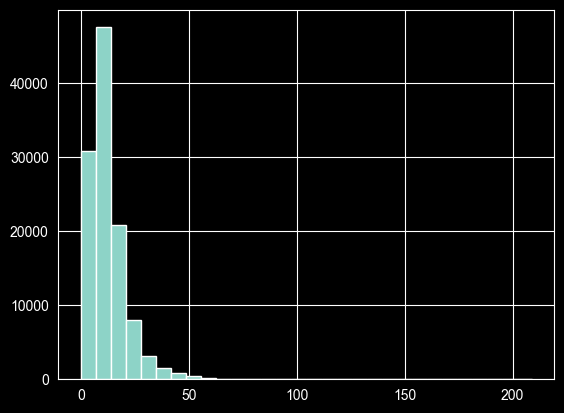

In [84]:
df['delivery_duration_days'].hist(bins=30)

In [85]:
import matplotlib.pyplot as plt


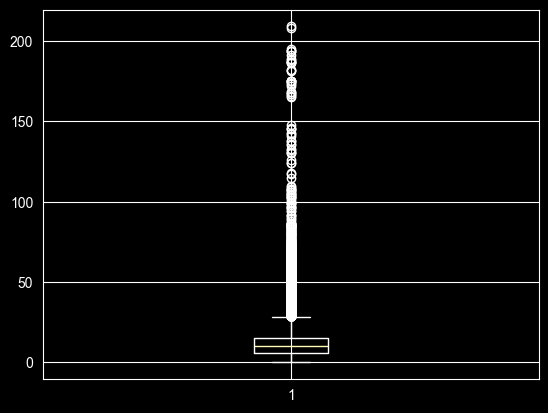

In [86]:
plt.boxplot(df['delivery_duration_days'])
plt.show()

In [87]:
df['delivery_duration_days'].skew()

np.float64(3.841285432649491)

In [88]:
df['delivery_duration_days'].quantile([0.90,0.95,0.99,0.995,0.999])

0.900    22.000
0.950    29.000
0.990    45.000
0.995    53.000
0.999    80.611
Name: delivery_duration_days, dtype: float64

In [89]:
# Convert to datetime first if they aren't already
df['order_approved_at'] = pd.to_datetime(df['order_approved_at'])
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# Calculate total seconds directly from the timestamp difference
df['approval_time_seconds'] = (
    df['order_approved_at'] - df['order_purchase_timestamp']
).dt.total_seconds()

In [90]:
print(df['approval_time_seconds'].value_counts())

approval_time_seconds
0.0         1487
730.0        136
697.0        135
760.0        135
722.0        128
            ... 
58394.0        1
140520.0       1
35655.0        1
78137.0        1
166894.0       1
Name: count, Length: 32289, dtype: int64


In [91]:
df['approval_time_seconds']=df['approval_time_seconds']/86400

In [92]:
# Ensure timestamp columns are in datetime format
df['order_approved_at'] = pd.to_datetime(df['order_approved_at'])
df['order_delivered_carrier_date'] = pd.to_datetime(df['order_delivered_carrier_date'])

# Calculate seller processing time in seconds or days
df['seller_processing_time_seconds'] = (
    df['order_delivered_carrier_date'] - df['order_approved_at']
).dt.total_seconds()

df['seller_processing_time_days'] = df['seller_processing_time_seconds'] / 86400

In [93]:
df["shipping_time"] = (
    df["order_delivered_customer_date"] -
    df["order_delivered_carrier_date"]
).dt.days

In [94]:
print(df[df['delivery_duration_days']==209][['shipping_time','seller_processing_time_days','approval_time_seconds']])

       shipping_time  seller_processing_time_days  approval_time_seconds
78317            195                    13.467025               1.127639


In [99]:
df['delivery_duration_days'].head()

0     7.0
1    15.0
2    17.0
3     8.0
4    13.0
Name: delivery_duration_days, dtype: float64

In [95]:
df.nlargest(20,'delivery_duration_days')[["order_id",
    "delivery_duration_days",
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "seller_state",
    "customer_state",
    "product_weight_g",
    "order_status"]]

,order_id,delivery_duration_days,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,seller_state,customer_state,product_weight_g,order_status
78317,ca07593549f1816d26a572e06dc1eab6,209.0,2017-02-21 23:31:27,2017-02-23 02:35:15,2017-03-08 13:47:46,2017-09-19 14:36:39,MG,ES,2800,delivered
17881,1b3190b2dfa9d789e1f14c05b647a14a,208.0,2018-02-23 14:57:35,2018-02-23 15:16:14,2018-02-26 18:49:07,2018-09-19 23:24:07,SP,RJ,1050,delivered
78292,440d0d17af552815d15a9e41abe49359,195.0,2017-03-07 23:59:51,2017-03-09 01:11:33,2017-03-15 13:00:08,2017-09-19 15:12:50,MG,PA,400,delivered
31320,0f4519c5f1c541ddec9f21b3bddd533a,194.0,2017-03-09 13:26:57,2017-03-09 13:26:57,2017-03-22 05:28:14,2017-09-19 14:38:21,SP,PI,4338,delivered
73187,2fb597c2f772eca01b1f5c561bf6cc7b,194.0,2017-03-08 18:09:02,2017-03-08 18:09:02,2017-03-13 08:54:02,2017-09-19 14:33:17,SP,PI,16133,delivered
97714,285ab9426d6982034523a855f55a885e,194.0,2017-03-08 22:47:40,2017-03-08 22:47:40,2017-03-09 08:53:20,2017-09-19 14:00:04,MG,SE,3100,delivered
109837,47b40429ed8cce3aee9199792275433f,191.0,2018-01-03 09:44:01,2018-01-03 10:31:15,2018-02-06 01:48:28,2018-07-13 20:51:31,SP,SP,30000,delivered
110646,2fe324febf907e3ea3f2aa9650869fa5,189.0,2017-03-13 20:17:10,2017-03-13 20:17:10,2017-03-17 07:23:53,2017-09-19 17:00:07,RS,SP,400,delivered
104514,2d7561026d542c8dbd8f0daeadf67a43,188.0,2017-03-15 11:24:27,2017-03-15 11:24:27,2017-03-16 09:29:16,2017-09-19 14:38:18,SP,SE,400,delivered
41552,437222e3fd1b07396f1d9ba8c15fba59,187.0,2017-03-16 11:36:00,2017-03-16 11:36:00,2017-03-21 08:22:43,2017-09-19 16:28:58,SP,AP,1500,delivered


In [96]:
df['order_delivered_customer_date'].value_counts().head(10)

order_delivered_customer_date
2017-08-14 12:46:18    63
2017-10-18 22:35:50    38
2017-06-22 16:04:46    26
2018-06-01 15:18:45    24
2017-07-27 20:52:15    24
2018-02-28 20:09:19    24
2017-03-21 13:32:45    24
2017-12-21 16:33:10    22
2017-07-31 18:03:02    21
2018-02-16 16:26:53    21
Name: count, dtype: int64

Bivariate EDA(numerical features)

In [97]:
num_features=df.select_dtypes(include='int').columns
for col in num_features:
    print(f'\n{col}')


Unnamed: 0

order_item_id

customer_zip_code_prefix

product_name_lenght

product_description_lenght

product_photos_qty

product_weight_g

product_length_cm

product_height_cm

product_width_cm

seller_zip_code_prefix

payment_sequential

payment_installments

year_of_purchase

shipping_time


In [100]:
new_df=df[['order_item_id','customer_zip_code_prefix','product_name_lenght',
'product_description_lenght','product_photos_qty',
'product_weight_g','product_length_cm',
'product_height_cm','product_width_cm',
'seller_zip_code_prefix','payment_sequential',
'payment_installments','year_of_purchase',
'shipping_time','delivery_duration_days']]


In [101]:
count=0
for col in new_df:
    count+=1
print(count)

15


In [102]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

scatter plot


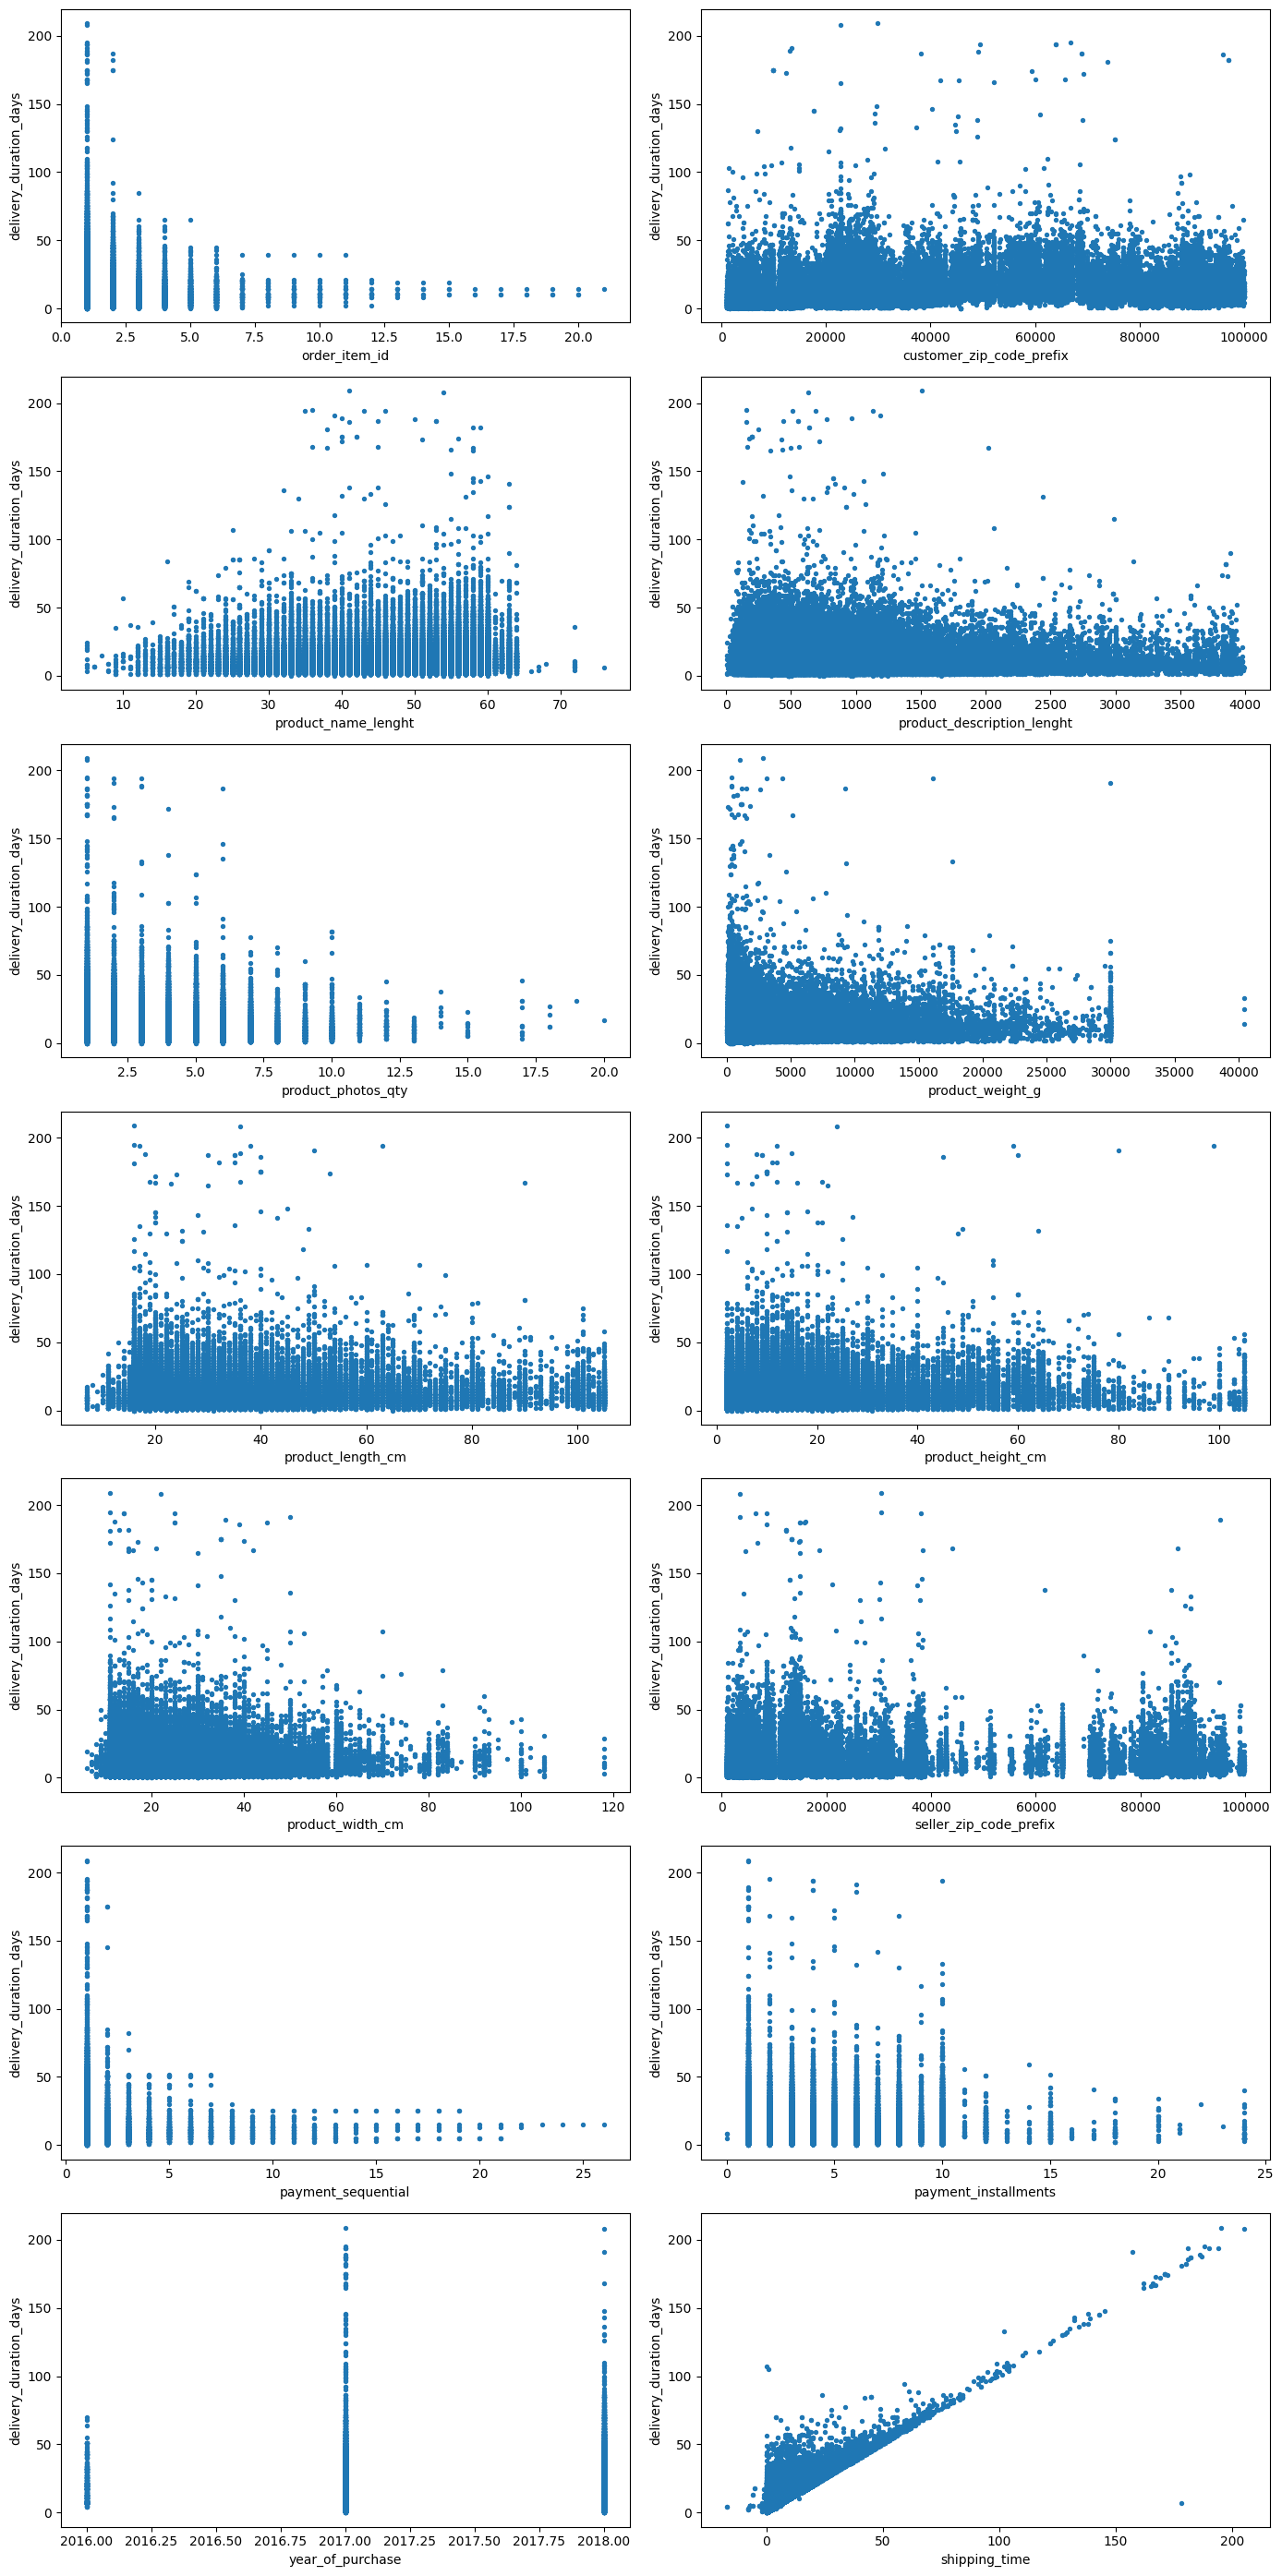

In [116]:
gs=gridspec.GridSpec(7,2)
print("scatter plot")
fig=plt.figure(figsize=(14,28))
plot_no=0
for col in new_df:
    if col !="delivery_duration_days":
        ax=fig.add_subplot(gs[plot_no])
        plt.scatter(new_df[col],new_df["delivery_duration_days"],alpha=1,s=8,label=col)
        ax.set_xlabel(col)
        ax.set_ylabel("delivery_duration_days")
        plot_no+=1
plt.tight_layout()
plt.show()


delivery_days

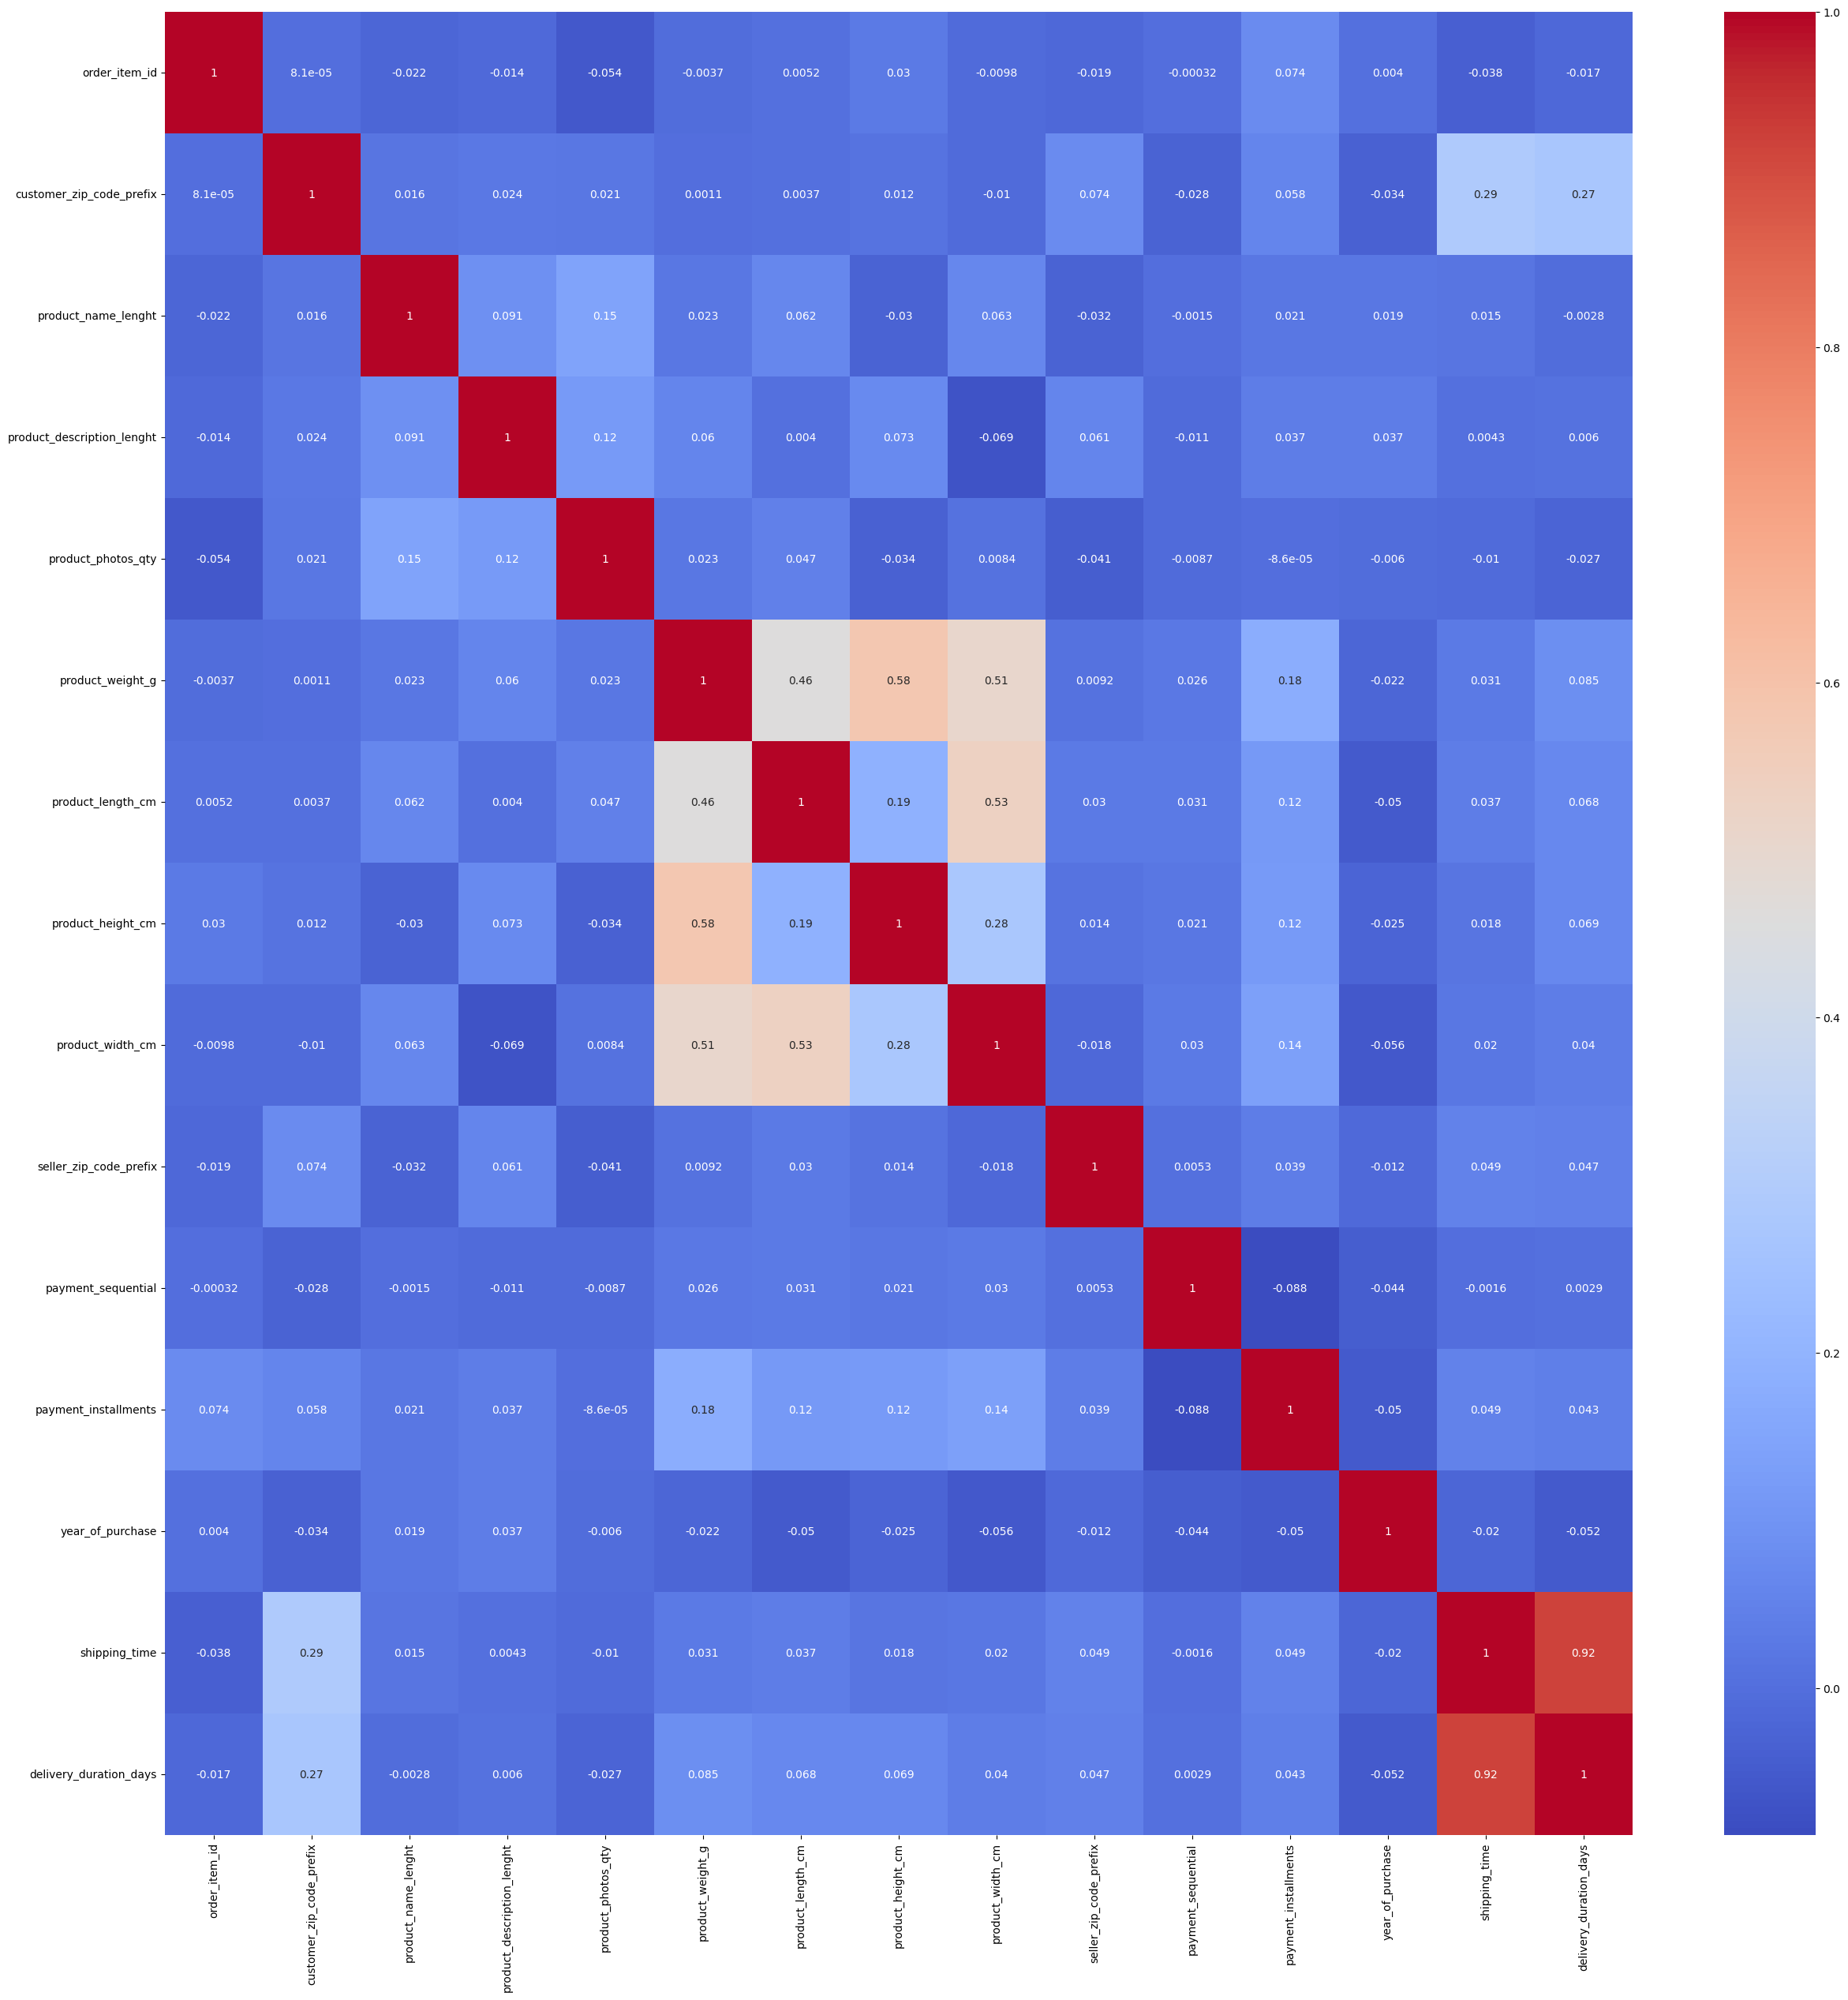

In [120]:
import seaborn as sns
plt.figure(figsize=(30,30))
sns.heatmap(new_df.corr(),annot=True,cmap='coolwarm.')
plt.show()

In [124]:
for col in new_df.columns:

    if col == "delivery_duration_days":
        continue

    if df[col].nunique() < 5:
        print(f"Skipping {col}")
        continue

    df[f"{col}_bin"] = pd.qcut(
        df[col],
        q=5,
        duplicates="drop"
    )

    print(f"\n{col}")

    print(
        df.groupby(f"{col}_bin")["delivery_duration_days"]
          .agg(["count", "mean", "median"])
    )


order_item_id
                    count       mean  median
order_item_id_bin                           
(0.999, 21.0]      113390  12.014622    10.0

customer_zip_code_prefix
                              count       mean  median
customer_zip_code_prefix_bin                          
(1002.999, 8295.0]            22690   7.456457     6.0
(8295.0, 18071.0]             22674   8.930758     7.0
(18071.0, 32071.0]            22675  13.657552    11.0
(32071.0, 71050.0]            22681  16.093647    14.0
(71050.0, 99980.0]            22670  13.936921    12.0

product_name_lenght
                         count       mean  median
product_name_lenght_bin                          
(4.999, 40.0]            23582  12.071326    10.0
(40.0, 48.0]             22294  12.083879    10.0
(48.0, 54.0]             24058  11.970987    10.0
(54.0, 58.0]             25247  11.983998    10.0
(58.0, 76.0]             18209  11.956505    10.0

product_description_lenght
                                count   

C:\Users\diksha\AppData\Local\Temp\ipykernel_13384\450858560.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(f"{col}_bin")["delivery_duration_days"]
C:\Users\diksha\AppData\Local\Temp\ipykernel_13384\450858560.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(f"{col}_bin")["delivery_duration_days"]
C:\Users\diksha\AppData\Local\Temp\ipykernel_13384\450858560.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and sile